# Preparation for Lab 1 - Northe, Velez, Wörner


The source code and the binaries from the spectrum analyzer from this report can be found in our Github [repository](https://github.com/NortheLo/Microwave_Eng_Lab/tree/main/Lab1_Network_Analysis).

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.constants import mu_0

## Task 1

The connection sketches are presented as follows:
### Filter:

![Prelim_Task1_Filter.png](Prelim_Task1_Filter.png)

### Circulator:
![Prelim_Task1_Circulator.png](Prelim_Task1_Circulator.png)

### Coupler:
![Prelim_Task1_Coupler.png](Prelim_Task1_Coupler.png)

### Line:
![Prelim_Task1_Line.png](Prelim_Task1_Line.png)

### Wilkinson Divider:
![Prelim_Task1_Wilk_Div.png](Prelim_Task1_Wilk_Div.png)

## Task 2

### a) Sketch the measurement setup of the amplifier measurement, which is described in Task 8 of the experimental tasks.

![pic](Prelim_Task3_Circuit.png)

### b) Find maximum power levels according to specifications of a network analyzer (input and output).

As there wasn't a specific model stated, we used this [Rohde & Schwarz ZNA67 datasheet](https://scdn.rohde-schwarz.com/ur/pws/dl_downloads/pdm/cl_brochures_and_datasheets/specifications/5215_4652_22/ZNA_specs_en_5215-4652-22_v2100.pdf)

**Output Test Port from page 24**

![title](ZNA67_max_power_level.png)

**Maximum Input Level from page 27**

At $+27dBm$ is the maximum power level, which can be accepted.

![title](ZNA67_max_damage_level.png)

### c) Determine the maximum allowed output power of a network analyzer for the amplifier of Task 8 without damaging the VNA.

Used [Datasheet of NLB-300](https://www.alldatasheet.com/datasheet-pdf/download/103781/RFMD/NLB-300.html)

The maximum allowed output power of the analyzer is limited to the maximum input values from the LNA. Here the datasheet states that $+20dBm$. <br>
But it has to be considered that the LNA is here way past its designed specifications. At this input level we exceed other parameters like 1dB-Compression point depending on the frequency at $\approx 13dBm$. 

## Task 3

### How do the 16-term, 12-term and 8-term error models differ? Specify the conditions that are assumed to apply to each.

When measuring S-parameters using a VNA, imperfections in the instrument, cables, and switching system introduce systematic errors. To correct for these, mathematical error models are used during calibration. Depending on the level of precision required and the type of measurement setup, different models are applied:

#### 16-Term Model
This is the most detailed model available. It accounts for all linear and systematic errors, including directivity, port match, tracking, leakage paths, and switch behavior. It's especially useful when working with wafer probes, fixtures, or setups where isolation and repeatability are more difficult to control.

#### 12-Term Model
A commonly used model in standard 2-port VNAs. It splits the error correction into six terms for the forward direction and six for the reverse. It captures the main sources of error like directivity, reflection/transmission tracking, and port mismatch. Assumes stable switching and relatively low leakage. Often used with SOLT calibration.

#### 8-Term Model
A simplified model that assumes perfect switching and negligible leakage. It models errors using two 2-port adapters — one at each port of the DUT. This model is efficient and accurate in modern VNAs with four receivers and is typically used with TRL calibration methods or when working with well-matched, symmetric setups.

| Model     | Terms | Assumptions                   | Best Suited For                     |
|-----------|-------|-------------------------------|-------------------------------------|
| 16-Term   | 16    | No assumptions                | Complex or high-precision setups    |
| 12-Term   | 12    | Ignores switch mismatch       | Standard lab measurements (SOLT)    |
| 8-Term    | 8     | Ideal switch, no leakage      | TRL calibration, modern instruments |




| Error Term             | Meaning / Description                            | 16-Term | 12-Term | 8-Term |
|------------------------|--------------------------------------------------|:-------:|:-------:|:------:|
| e00 / e33              | Directivity (Fwd / Rev)                          |   ✅    |   ✅    |   ✅   |
| e11 / e22              | Source Match (Fwd / Rev)                         |   ✅    |   ✅    |   ✅   |
| e10·e32 / e23·e01      | Reflection Tracking (Fwd / Rev)                  |   ✅    |   ✅    |   ✅   |
| e30 / e21              | Load Match (Fwd / Rev)                           |   ✅    |   ✅    |        |
| e43 / e12              | Transmission Tracking (Fwd / Rev)               |   ✅    |   ✅    |   ✅   |
| e03 / e21              | Crosstalk / Isolation (Fwd / Rev)               |   ✅    |         |        |
| Assumed Symmetry       | Hardware is reciprocal                          |         |   ✅    |   ✅   |
| Assumed Isolation      | No Crosstalk                                     |         |         |   ✅   |
| Assumed Identical Ports| Ports behave identically                         |         |         |   ✅   |


## Task 4

### Why is a cable usually standardized to 50 Ohm in microwave technology? What are the advantages?

**50 Ω** is a standardized impedance because it represents a compromise between two competing performance metrics:

- **Maximum power handling** (optimized near **30 Ω**)  
- **Minimum conductor loss** (optimized near **77 Ω**)

---

#### Maximum Power Handling

The peak power is limited by the **electric field strength** at the inner conductor, which must not exceed the dielectric breakdown limit.

Electric field at the inner conductor:

$$
E_{\text{max}} = \frac{V}{a \ln(b/a)}
$$

Solving for the maximum voltage before breakdown $ E_{\text{break}} $:

$$
V_{\text{max}} = E_{\text{break}} \cdot a \ln(b/a)
$$

Power delivered to a matched load:

$$
P = \frac{V_{\text{max}}^2}{2Z_0}
$$

Substitute for \( V_{\text{max}} \):

$$
P \propto \frac{a^2 \ln^2(b/a)}{Z_0}
$$

From the impedance formula:

$$
Z_0 = \frac{60}{\sqrt{\varepsilon_r}} \ln(b/a)
\Rightarrow
P \propto \frac{a^2 \ln(b/a)}{60}
$$

This expression peaks near $ Z_0 \approx 30\ \Omega $, where the cable supports **maximum power** before dielectric breakdown.

---

#### Minimum Attenuation

In the low-loss approximation, the attenuation constant is:

$$
\alpha \approx \frac{R_s}{2Z_0} \left( \frac{1}{a} + \frac{1}{b} \right)
$$

Using:

$$
Z_0 = \frac{60}{\sqrt{\varepsilon_r}} \ln(b/a)
$$

We substitute and minimize $ \alpha $ with respect to the ratio $ \frac{b}{a} $. The optimal value for **minimum attenuation** is:

$$
Z_0 \approx 77\ \Omega
$$

---

The choice of **50 Ω** impedance is a practical engineering compromise:

- Closer to **30 Ω** for good power handling  
- Close enough to **77 Ω** for relatively low conductor loss. Some applications like TV infrastructure, where $75\Omega$ is often used to prioritize this.

This makes 50 Ω a well-balanced standard for **RF/microwave** applications.

In [5]:
b = 1.0  # outer conductor radius (normalized)
epsilon_r = 1.0  # air dielectric constant

In [6]:
a = np.linspace(0.01, 0.9 * b, 500)
ln_ba = np.log(b / a)

Z0 = 60 / np.sqrt(epsilon_r) * ln_ba
Vmax = a * ln_ba
P = Vmax**2 / (2 * Z0)
P_normalized = P / np.max(P)

alpha = (1 / Z0) * (1 / a + 1 / b)
alpha_normalized = alpha / np.min(alpha)

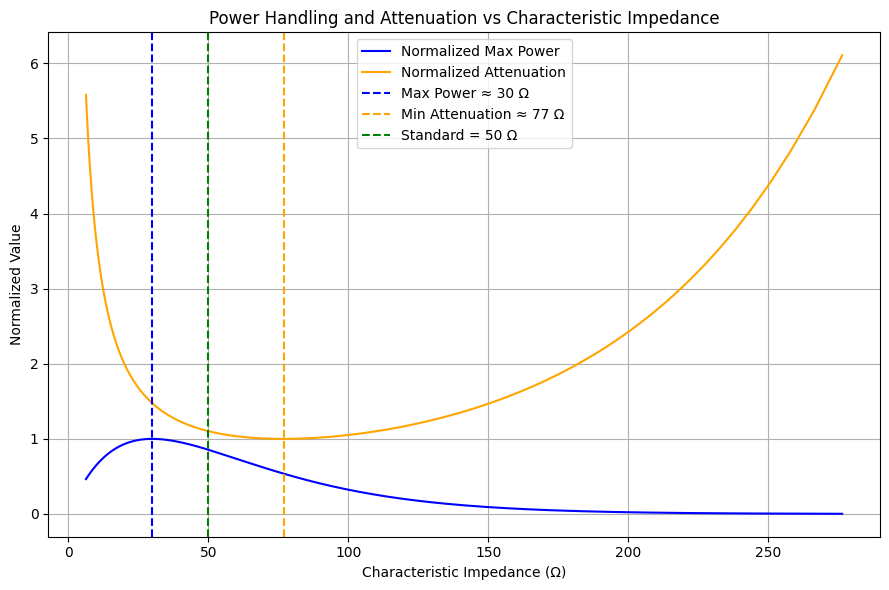

In [ ]:
plt.figure(figsize=(9, 6))
plt.plot(Z0, P_normalized, label='Normalized Max Power', color='blue')
plt.plot(Z0, alpha_normalized, label='Normalized Attenuation', color='orange')

plt.axvline(30, color='blue', linestyle='--', label='Max Power ≈ 30 Ω')
plt.axvline(77, color='orange', linestyle='--', label='Min Attenuation ≈ 77 Ω')
plt.axvline(50, color='green', linestyle='--', label='Standard = 50 Ω')

plt.xlabel('Characteristic Impedance (Ω)')
plt.ylabel('Normalized Value')
plt.title('Power Handling and Attenuation vs Characteristic Impedance')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

[1] https://www.microwaves101.com/encyclopedias/coax-loss-calculations <br>
[2] https://www.microwaves101.com/encyclopedias/why-fifty-ohms <br>
[3] https://www.allaboutcircuits.com/technical-articles/introduction-to-vna-calibration-techniques/ <br>
[4] https://www.allaboutcircuits.com/technical-articles/understanding-the-12-term-error-model-and-solt-calibration-method-for-vna-measurements/ <br>
[5] http://emlab.uiuc.edu/ece451/appnotes/Rytting_NAModels.pdf